In [11]:
import connector1 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = connector1.get_connection()
cursor = conn.cursor()


In [12]:
import mysql.connector
import pandas as pd
csv_path = "data/sales_data.csv"
df = pd.read_csv(csv_path)
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], dayfirst=True).dt.strftime('%Y-%m-%d')
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [13]:
for i, row in df.iterrows():
    sql = """INSERT INTO sales (
        Product_ID, Sale_Date, Sales_Rep, Region, Sales_Amount, Quantity_Sold,
        Product_Category, Unit_Cost, Unit_Price, Customer_Type, Discount,
        Payment_Method, Sales_Channel, Region_and_Sales_Rep
    ) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)"""
cursor.execute(sql, tuple(row))
conn.commit()


In [14]:
cursor.execute("SELECT COUNT(*) FROM sales;")
print("Total rows in sales table:", cursor.fetchone()[0])

cursor.execute("SELECT * FROM sales LIMIT 5;")
for row in cursor.fetchall():
    print(row)


Total rows in sales table: 2007
(1052, datetime.date(2023, 2, 3), 'Bob', 'North', 5053.97, 18, 'Furniture', 152.75, 267.22, 'Returning', 0.09, 'Cash', 'Online', 'North-Bob')
(1093, datetime.date(2023, 4, 21), 'Bob', 'West', 4384.02, 17, 'Furniture', 3816.39, 4209.44, 'Returning', 0.11, 'Cash', 'Retail', 'West-Bob')
(1015, datetime.date(2023, 9, 21), 'David', 'South', 4631.23, 30, 'Food', 261.56, 371.4, 'Returning', 0.2, 'Bank Transfer', 'Retail', 'South-David')
(1072, datetime.date(2023, 8, 24), 'Bob', 'South', 2167.94, 39, 'Clothing', 4330.03, 4467.75, 'New', 0.02, 'Credit Card', 'Retail', 'South-Bob')
(1061, datetime.date(2023, 3, 24), 'Charlie', 'East', 3750.2, 13, 'Electronics', 637.37, 692.71, 'New', 0.08, 'Credit Card', 'Online', 'East-Charlie')


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())       
print(df.describe())   
print(df['Region'].value_counts())  
print(df['Product_Category'].value_counts()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB
None
        P

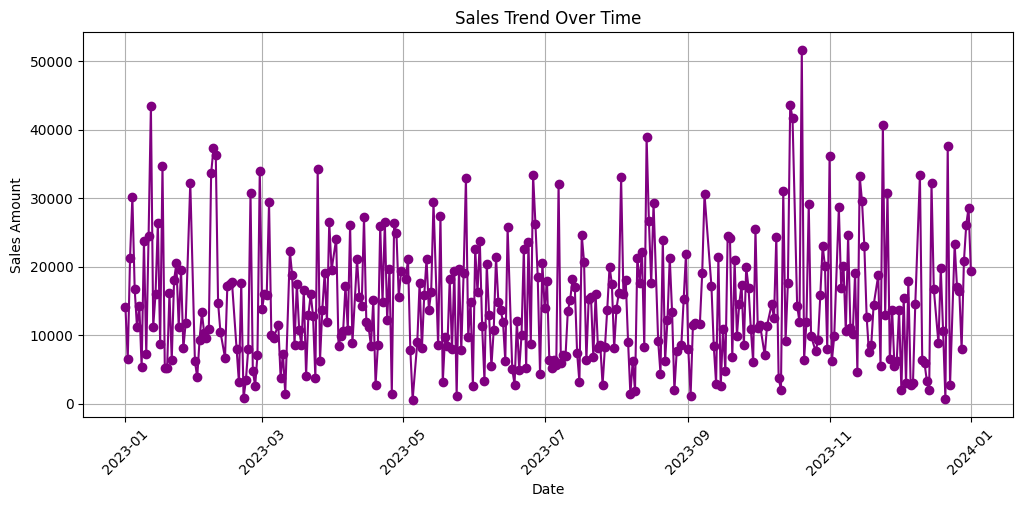

In [16]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])
sales_over_time = df.groupby('Sale_Date')['Sales_Amount'].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_over_time.index, sales_over_time.values, marker='o', color='purple')
plt.title('Sales Trend Over Time')
plt.ylabel('Sales Amount')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


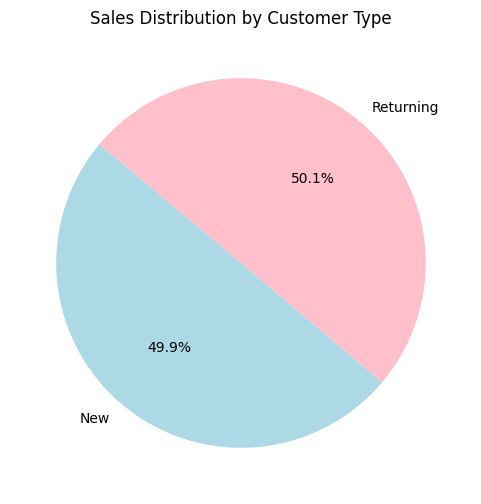

In [18]:
sales_by_customer = df.groupby('Customer_Type')['Sales_Amount'].sum()
plt.figure(figsize=(6,6))
plt.pie(sales_by_customer.values, 
        labels=sales_by_customer.index, 
        autopct='%1.1f%%', 
        colors=['lightblue','pink'],
        startangle=140)
plt.title('Sales Distribution by Customer Type')
plt.show()
